In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    mode="full_curve",       
    train_data_rels=["datas/oldroyd-rom3"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (0.5, 9.0),
    beta_bounds = (0.1, 0.95),
    eta0_bounds = (0.5, 2.0),
    pressure_filename="pressure_drop.txt",
    scaler="minmax",
    eps=1e-6,
    sigma_noise_percent=1.0,
    thin=1,
    sigma_bias="infer",
    l_bias = "infer",
    correlation_matrix= "squared",
    constrained_model_error=True,
    use_pressure=True,
    augment_eta0=True,
    true_theta=None)

model.load_data(filename="datas/oldroyd-rom3/beta-0.5/alpha-0.2/wi-4/curve4_y.txt",
                u_avg_obs=0.1)

model.plot_data()
model.build_rom()
model.plot_prior()
model.run_mcmc(nwalkers=15, nsteps=15000, burn_fraction=0.5)
model.compute_N1()  
model.plot_corner_all()
model.plot_posterior_predictive()
model.plot_trace_all()

l = 0.5:  std[delta(0)] = 4.59e-11   max std[delta'] on [4,5] = 1.01e-03   min eig(K) = -6.59e-09
l = 0.9:  std[delta(0)] = 6.67e-07   max std[delta'] on [4,5] = 6.95e-03   min eig(K) = -2.56e-06


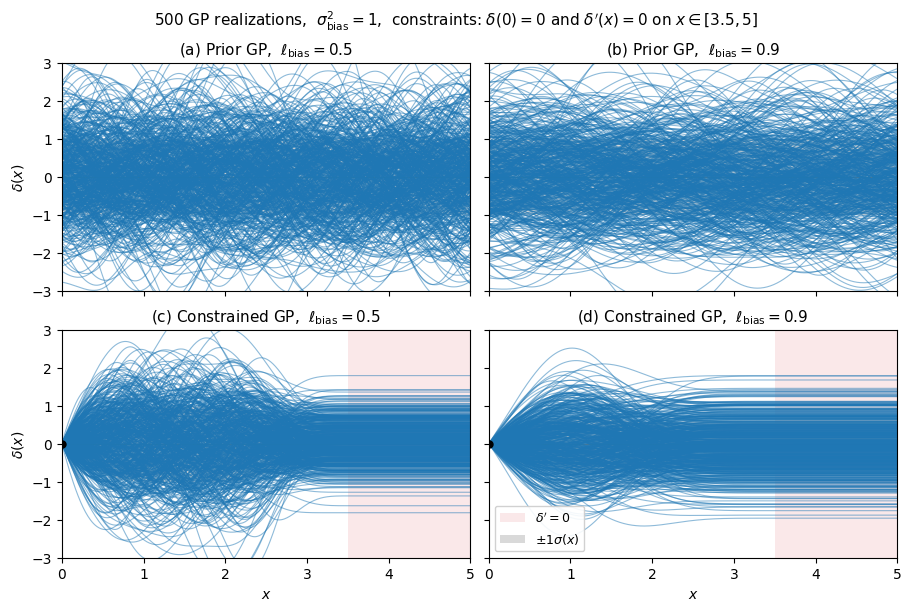

In [1]:
"""
GP realizations under linear (derivative) constraints.

Kernel:  k(x,x') = sigma^2 * exp(-0.5 (x-x')^2 / l^2),  sigma^2 = 1

Constraints imposed exactly (noise-free):
    delta(0)   = 0
    delta'(xd) = 0   for 20 evenly spaced xd in [4, 5]

Top row  = unconstrained prior, bottom row = constrained, for l = 0.5 and 0.9.
"""

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

# ======================================================================
# Model parameters
# ======================================================================
SIGMA2_BIAS = 1.0                   # sigma_bias^2 : marginal variance of delta
ELL_BIAS = [0.5, 0.9]               # l_bias       : correlation lengths to compare

# Constraint locations
X0 = np.array([0.0])                # delta(x)  = 0 here
XD = np.linspace(3.5, 5.0, 10)      # delta'(x) = 0 here (20 evenly spaced)

# Sampling / grid
N_SAMPLES = 500
X_GRID = np.linspace(0.0, 5.0, 500)

# Shaded envelope: +/- BAND_SIGMA * sigma(x).
# With BAND_SIGMA = 1 the band is +/- sigma, so sigma_bias^2 = 1 gives a band
# of total width 2 (set it to 2 for the conventional ~95% envelope instead).
BAND_SIGMA = 1.0
# ======================================================================


# ----------------------------------------------------------------------
# Kernel and its derivatives
#   r = x - x'
#   k    (x, x') = s2 * exp(-r^2 / 2l^2)
#   k_fd (x, x') = cov(f(x), f'(x'))  = d k / dx' = ( r / l^2) k
#   k_dd (x, x') = cov(f'(x), f'(x')) = d2k/dxdx' = (1/l^2 - r^2/l^4) k
# ----------------------------------------------------------------------

def k_ff(x, y, ell, s2=SIGMA2_BIAS):
    r = np.subtract.outer(x, y)
    return s2 * np.exp(-0.5 * (r / ell) ** 2)


def k_fd(x, y, ell, s2=SIGMA2_BIAS):
    r = np.subtract.outer(x, y)
    return s2 * (r / ell**2) * np.exp(-0.5 * (r / ell) ** 2)


def k_dd(x, y, ell, s2=SIGMA2_BIAS):
    r = np.subtract.outer(x, y)
    return s2 * (1.0 / ell**2 - r**2 / ell**4) * np.exp(-0.5 * (r / ell) ** 2)


# ----------------------------------------------------------------------
# Conditioning
# ----------------------------------------------------------------------

def constrained_covariance(x, ell):
    """Cov of the GP conditioned on f(0)=0 and f'(XD)=0."""
    Kff = k_ff(x, x, ell)

    # cov(f(x), g) where g = [f(0), f'(XD)]
    Kfg = np.hstack([k_ff(x, X0, ell), k_fd(x, XD, ell)])

    # cov(g, g)
    Kgg = np.block([
        [k_ff(X0, X0, ell),   k_fd(X0, XD, ell)],
        [k_fd(X0, XD, ell).T, k_dd(XD, XD, ell)],
    ])

    A = Kfg @ np.linalg.pinv(Kgg, rcond=1e-10)
    Kc = Kff - A @ Kfg.T
    return 0.5 * (Kc + Kc.T)     

def prior_covariance(x, ell):
    return k_ff(x, x, ell)

def draw(K, n, rng):
    """Sample from N(0, K) via eigendecomposition (robust to tiny negatives)."""
    w, V = np.linalg.eigh(K)
    L = V * np.sqrt(np.clip(w, 0.0, None))
    return rng.normal(size=(n, K.shape[0])) @ L.T

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------

x = X_GRID

fig, axes = plt.subplots(2, 2, figsize=(9, 6),
                         sharex=True, sharey=True,
                         constrained_layout=True)

labels = ["(a)", "(b)", "(c)", "(d)"]

for row, constrained in enumerate([False, True]):
    for col, ell in enumerate(ELL_BIAS):
        ax = axes[row, col]

        K = constrained_covariance(x, ell) if constrained else prior_covariance(x, ell)
        samples = draw(K, N_SAMPLES, rng)
        std = np.sqrt(np.clip(np.diag(K), 0.0, None))

        if constrained:
            ax.axvspan(XD[0], XD[-1], color="tab:red", alpha=0.10, lw=0,
                       label=r"$\delta'=0$")

        ax.fill_between(x, -BAND_SIGMA * std, BAND_SIGMA * std,
                        color="0.85", lw=0, zorder=0,
                        label=rf"$\pm{BAND_SIGMA:g}\sigma(x)$")
        ax.plot(x, samples.T, color="tab:blue", lw=0.8, alpha=0.5)
        ax.axhline(0, color="0.4", lw=0.6, zorder=1)

        if constrained:
            ax.plot(0, 0, "ko", ms=5, zorder=5)

        kind = "Constrained" if constrained else "Prior"
        ax.set_title(rf"{labels[2*row+col]} {kind} GP,  $\ell_{{\rm bias}}={ell}$",
                     fontsize=11)
        ax.set_xlim(X_GRID[0], X_GRID[-1])
        ax.set_ylim(-3, 3)

axes[1, 0].set_xlabel(r"$x$")
axes[1, 1].set_xlabel(r"$x$")
axes[0, 0].set_ylabel(r"$\delta(x)$")
axes[1, 0].set_ylabel(r"$\delta(x)$")
axes[1, 1].legend(loc="lower left", fontsize=9, framealpha=0.9)

fig.suptitle(
    rf"{N_SAMPLES} GP realizations,  $\sigma^2_{{\rm bias}}={SIGMA2_BIAS:g}$,  "
    rf"constraints: $\delta({X0[0]:g})=0$ and "
    rf"$\delta'(x)=0$ on $x\in[{XD[0]:g},{XD[-1]:g}]$",
    fontsize=11)

fig.savefig("gp_constrained.png", dpi=150)


# ----------------------------------------------------------------------
# Check that the constraints are actually enforced
# ----------------------------------------------------------------------

for ell in ELL_BIAS:
    Kc = constrained_covariance(x, ell)
    s = draw(Kc, 2000, rng)
    dsdx = np.gradient(s, x, axis=1)
    print(f"l = {ell}:  std[delta(0)] = {s[:, 0].std():.2e}   "
          f"max std[delta'] on [4,5] = "
          f"{dsdx[:, (x >= 4) & (x <= 5)].std(axis=0).max():.2e}   "
          f"min eig(K) = {np.linalg.eigvalsh(Kc).min():.2e}")

plt.show()